In [61]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
#Carga desde un archivo .csv sin indice
plazas= pd.read_csv('Analisis GAC Full7agosto 2026(Plazas).csv') 

C:\Users\maria\AppData\Local\Temp\ipykernel_2036\500712103.py:2: DtypeWarning: Columns (0: Fecha Origen, 1: Nombre, 2: Producto, 3: Asesor, 4: Origen, 5: Seguimiento, 6: Cita efetiva , 7: PDM, 8: SDC, 9: Estatus, 10: ¿Por que no hay seguimiento?, 11: ¿Por que no ha visitado la agencia?, 12: ¿Por que no hubo prueba de manejo ?, 13: ¿Por que no hubo solicitud de credito?, 14: ¿Por que no se ha formalizado la compra?, 15: Unnamed: 16, 16: Unnamed: 19) have mixed types. Specify dtype option on import or set low_memory=False.
  plazas= pd.read_csv('Analisis GAC Full7agosto 2026(Plazas).csv')


In [63]:
#Verificamos información del DataFrame
plazas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 20 columns):
 #   Column                                    Non-Null Count    Dtype  
---  ------                                    --------------    -----  
 0   Fecha Origen                              302 non-null      str    
 1   Nombre                                    303 non-null      str    
 2   Telefono                                  26 non-null       float64
 3   Producto                                  303 non-null      str    
 4   Asesor                                    303 non-null      str    
 5   Origen                                    303 non-null      str    
 6   Seguimiento                               1048567 non-null  object 
 7   Cita efetiva                              1048564 non-null  object 
 8   PDM                                       1048563 non-null  object 
 9   SDC                                       1048563 non-null  object 
 10  Estatus          

In [64]:
#Imprimo los primeros 5 registro del dataframe
plazas.head()

,Fecha Origen,Nombre,Telefono,Producto,Asesor,Origen,Seguimiento,Cita efetiva,PDM,SDC,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,05/06/2025 18:30,Alejandro Fernandez,NaN,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,True,False,False,False,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,05/06/2025 18:00,David Israel,NaN,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,True,False,False,False,Finalizado,Si hay seguimiento,Dejo de contestar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05/06/2025 13:50,Rosendo Ceron,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05/06/2025 13:47,Fausto Ochoa Martinez,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05/06/2025 13:43,Brigida Lara Perez,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN


¿Por que no ha visitado la agencia?

In [65]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = plazas['¿Por que no ha visitado la agencia?'].value_counts().reset_index()
Tabla_freq

,¿Por que no ha visitado la agencia?,count
0,Dejo de contestar,17
1,Se invita a evento,8
2,Ya visito la agencia,6
3,"Ya se hizo la invitación, eperando respuesta",5
4,Dejo de contestar,4
...,...,...
105,"Dejo de contestar, es foranea",1
106,Dejo de contestar,1
107,"Cita dom 8, no asistio el cliente",1
108,"Esta vendiendo su camioneta, cita miercoles 11",1


In [66]:
# Extraigo la pregunta abierta
Pregunta_abierta = plazas[
    ["¿Por que no ha visitado la agencia?"]
].copy()

# Elimino las respuestas vacías
Pregunta_abierta = Pregunta_abierta.dropna()

Pregunta_abierta

,¿Por que no ha visitado la agencia?
0,"Recibe recurso a finales de junio, proyección ..."
1,Dejo de contestar
2,"Ya se hizo la invitación, eperando respuesta"
3,"Ya se hizo la invitación, eperando respuesta"
4,"Ya se hizo la invitación, eperando respuesta"
...,...
271,Ya visito la agencia
272,Dejo de contestar
273,"Cita dom 8, no asistio el cliente"
1048548,"Esta vendiendo su camioneta, cita miercoles 11"


In [67]:
# Creo una categoría general
Pregunta_abierta["Caracteristica"] = "Pérdida de contacto"

# Falta de respuesta / pérdida de contacto
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "dejo de contestar|dejo de contestra|no contesta|no responde|buzon|"
        "no da respuesta|se insiste el contacto",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Pérdida de contacto"

In [68]:
# Sigue evaluando información, cotizaciones, modelos o marcas
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "evaluando|revisando|revisar|cotización|cotizacion|información|"
        "informacion|modelos|marcas",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sigue evaluando"

In [69]:
# Falta de tiempo, viajes o distancia
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "no tiene tiempo|no ha tenido tiempo|tema de tiempos|viaje|vacaciones|"
        "fuera|no esta en puebla|oaxaca|veracruz|yucatan|tlaxco|canada|"
        "trabaja en mexico|foranea",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Falta de tiempo o ubicación"

In [70]:
# Compra proyectada para después
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "compra 2 o 3 meses|compra diciembre|compra fin de año|"
        "finales de año|fin de año|proyección de compra|proyeccion de compra|"
        "finales de junio|cuando regrese",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Compra futura"

In [71]:
# Problemas económicos o de financiamiento
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "mensualidades|mensales|buro|bajos ingresos|recurso|"
        "estados de cuenta|enganche|credito|crédito|"
        "meses sin intereses",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Limitaciones económicas"

In [72]:
# Ya existe una cita o está por realizarse
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "cita|confirmar fecha|por confirmar|reprograma|agenda cita|"
        "quiere venir|contactar para prueba",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Cita pendiente"

In [73]:
# Registros donde realmente ya hubo visita
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no ha visitado la agencia?"]

    .str.contains(
        "ya visito|ya vino|ya tuvo cita|vio la unidad",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Ya visitó la agencia"

In [74]:
Pregunta_abierta

,¿Por que no ha visitado la agencia?,Caracteristica
0,"Recibe recurso a finales de junio, proyección ...",Limitaciones económicas
1,Dejo de contestar,Pérdida de contacto
2,"Ya se hizo la invitación, eperando respuesta",Pérdida de contacto
3,"Ya se hizo la invitación, eperando respuesta",Pérdida de contacto
4,"Ya se hizo la invitación, eperando respuesta",Pérdida de contacto
...,...,...
271,Ya visito la agencia,Ya visitó la agencia
272,Dejo de contestar,Pérdida de contacto
273,"Cita dom 8, no asistio el cliente",Cita pendiente
1048548,"Esta vendiendo su camioneta, cita miercoles 11",Cita pendiente


In [75]:
Tabla_caracteristicas = (

    Pregunta_abierta["Caracteristica"]

    .value_counts()

    .reset_index()

)

Tabla_caracteristicas

,Caracteristica,count
0,Pérdida de contacto,79
1,Ya visitó la agencia,18
2,Sigue evaluando,18
3,Cita pendiente,17
4,Falta de tiempo o ubicación,16
5,Limitaciones económicas,13
6,Compra futura,8


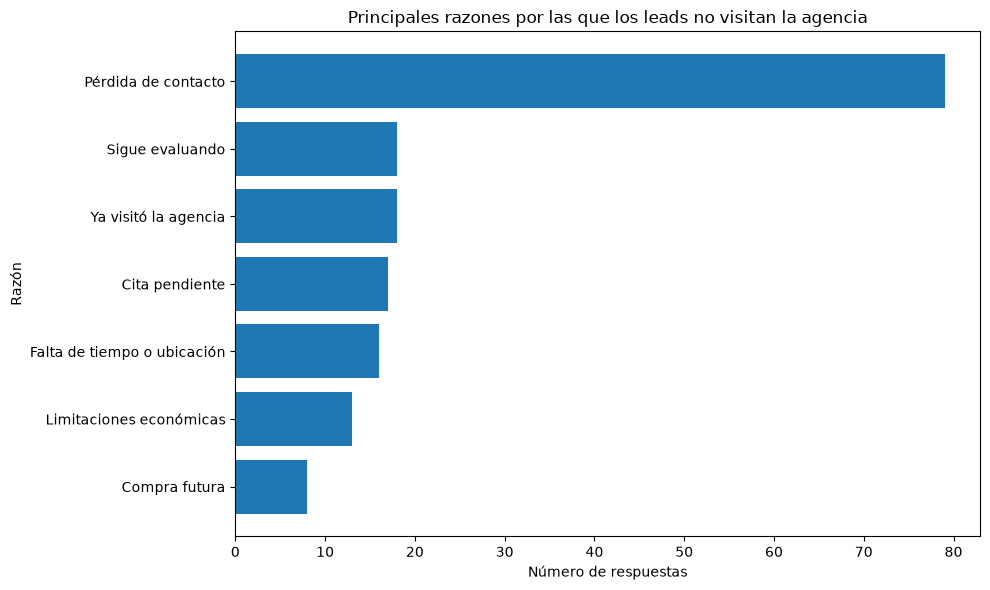

In [76]:
import matplotlib.pyplot as plt

# Ordeno las categorías de mayor a menor
Tabla_caracteristicas = Tabla_caracteristicas.sort_values(
    by="count",
    ascending=True
)

# Creo la gráfica
plt.figure(figsize=(10, 6))

plt.barh(
    Tabla_caracteristicas["Caracteristica"],
    Tabla_caracteristicas["count"]
)

plt.title("Principales razones por las que los leads no visitan la agencia")
plt.xlabel("Número de respuestas")
plt.ylabel("Razón")

plt.tight_layout()
plt.show()